![logo](./img/LogoLine_horizon_C3S.png)

## Getting and plotting 2m temperature from CARRA

CARRA data can be found in the CDS (Copernicus Climate Data Store, https://cds.climate.copernicus.eu/cdsapp#!/home).
The CARRA entries are at https://cds.climate.copernicus.eu/cdsapp#!/search?text=CARRA.
Here the single levels are chosen for the 2m temperature (also to limit the size of the data).
You need to create a CDS account and accept the terms and conditions for all datasets that you want to use.

### Fetching CARRA data
The source code below will download a specific month. By specifying the start and end date below one can easily download longer periods. We are selecting 2m temperature and single levels. 
Here, we download the 3-hourly analysis time steps and the data will be stored in a specified file.

![logo](./img/climatology_banner.png)

<style>
td, th {
   border: 1px solid white;
   border-collapse: collapse;
}
</style>
<table align="left">
  <tr>
    <th>
      To run the notebooks in the cloud environment click on the icons for "binder" or "kaggle" or "colab" in the menubar below.<br><br>
      <div>
        <a href="https://mybinder.org/v2/gh/ecmwf-projects/copernicus-training-c3s/main?labpath=reanalysis-climatology.ipynb">
          <img src="https://mybinder.org/badge.svg" alt="Binder">
        </a>
        <a href="https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Kaggle">
        </a>
        <a href="https://colab.research.google.com/github/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab">
        </a>
      </div>
    </th>
  </tr>
</table>


#### Install CDS API

Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need.

To install the CDS API, run the following command. We use an exclamation mark to pass the command to the shell (not to the Python interpreter).

In [1]:
#!pip install cdsapi #Uncomment this part if cdsapi is not installed

#### Enter your CDS API key

We will request data from the Climate Data Store (CDS) programmatically with the help of the CDS API. Let us make use of the option to manually set the CDS API credentials. First, you have to define two variables: `URL` and `KEY` which build together your CDS API key. The string of characters that make up your KEY include your personal User ID (UID) and CDS API key. To obtain these, first register or login to the CDS (http://cds.climate.copernicus.eu), then visit https://cds.climate.copernicus.eu/api-how-to and copy the string of characters listed after "key:". Replace the `#########` below with this string. Note that you need to combine the UID and CDS API key following the format `"UID:KEY"`


In [17]:
import os
import cdsapi
import warnings
warnings.filterwarnings('ignore') #turn off some warnings
import cdsapi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr


In [2]:
# Here one specifies the domain, year and period to download
URL = "https://cds.climate.copernicus.eu/api/v2"
KEY = "#########" #REPLACE with your own API KEY
yearStart = 2024 #first year to download
yearEnd   = 2024 #last year to download
monthStart =  3 # first month to download
monthEnd   =  3 #last month to download
days = [str(i).zfill(2) for i in range(1,31)] # the list of days to download. Adapt day number for other months
period="202403" # the period to plot later

domain = 'west_domain' # the domain to select. Use "east_domain" for the East domain
# the local directory where the data will be stored
DATADIR="CARRA"

        

---

In [8]:

# create directory to store CARRA data if it does not exist already:
if not os.path.isdir(DATADIR):
    os.makedirs(os.path.join(DATADIR,"Raw_data"))
c = cdsapi.Client(url=URL,key=KEY)

# define a helper function to download the data
# Note that the time is hardcoded since we are selecting
# all possible available times. 
def fetch_one_month(month, year, days, domain):
    c.retrieve(
        'reanalysis-carra-single-levels',
        {
            'format': 'grib',
            'domain': domain ,
            'level_type': 'surface_or_atmosphere',
            'variable': '2m_temperature',
            'product_type': 'analysis',
            'year': year,
            'month': month,
            'day': days,
            'time': [
                '00:00', '03:00', '06:00',
                '09:00', '12:00', '15:00',
                '18:00', '21:00',
            ],
        },
        os.path.join(DATADIR,"Raw_data",'T2m_an_'+str(year)+"{:02d}".format(month)+'.grb'))

    



In [9]:
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("Data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)")
        fetch_one_month(month, year, days, domain)

Data will be fetched for  2024 3
This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)


2024-08-15 15:13:54,682 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-15 15:13:54,683 WARNING MOVE TO CDS-Beta
2024-08-15 15:13:54,683 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-carra-single-levels
2024-08-15 15:13:55,016 INFO Request is queued
2024-08-15 15:14:16,257 INFO Request is running
2024-08-15 15:14:44,911 INFO Request is completed
2024-08-15 15:14:44,913 INFO Downloading https://download-0017.copernicus-climate.eu/cache-compute-0017/cache/data4/adaptor.mars.external-1723727653.2077796-20077-10-3f86b3c1-cc11-47f0-97

## Plotting the data


### Calculating the monthly mean

We will compute the monthly mean for 2m temperature and plot the result on a map. This is done for training purposes, but in principle
monthly means will be readily available for download for CARRA.

In [20]:
# Compute monthly mean
print("Computing the mean...")
CARRA_mean = CARRA.mean(dim="time", keep_attrs=True)
# Change longitudes from 0-360 to -180 to 180, needed for the plotting
CARRA_mean = CARRA_mean.assign_coords(longitude=(((CARRA_mean.longitude + 180) % 360) - 180))

# Change unit from K to C and add the unit to the attributes
CARRA_mean_C = CARRA_mean - 273.15
CARRA_mean_C = CARRA_mean_C.assign_attrs(CARRA_mean.attrs)
CARRA_mean_C.attrs['units'] = 'deg C'

print("Done.")


Computing the mean...
Done.


### Simple plot
The data array can be plotted directly with the available plot function.
Note that things like the title and the colorbar including the units are set automatically based on the information in the metadata.
To save the plot, we import the package "matplotlib".


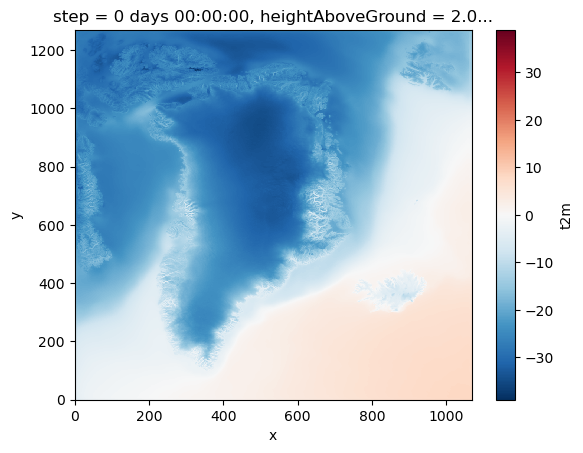

In [22]:
CARRA_mean_C["t2m"].plot()
PLOTS=os.path.join(DATADIR,"Figures")
if not os.path.isdir(PLOTS):
    os.makedirs(PLOTS)
    
plt.savefig(os.path.join(PLOTS,'CARRA_'+domain+'_'+period+'_simple.png'))

### Detailed plot
We plot the data again using latitude and longitude coordinates and selecting lat lon projection

Plotting CARRA and saving the figure


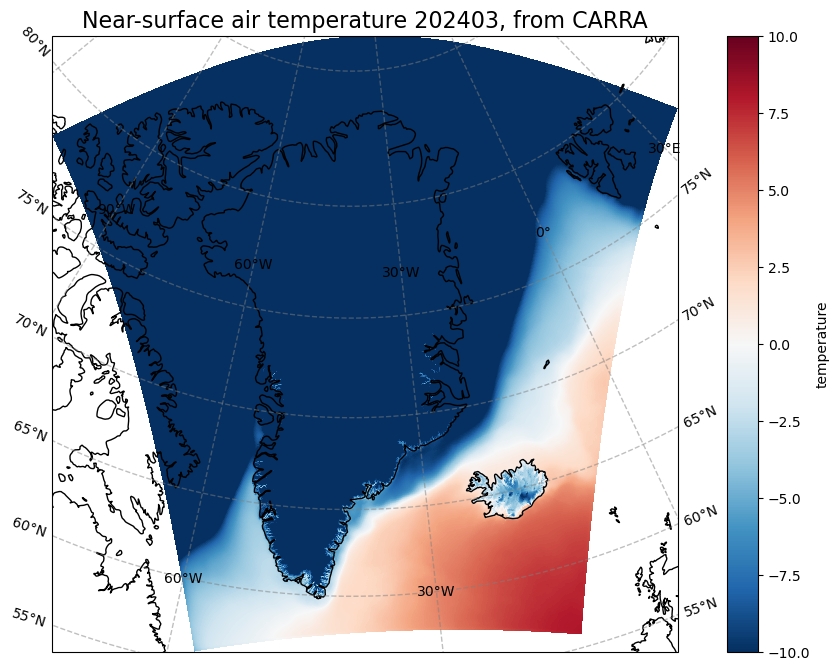

In [13]:
print("Plotting CARRA mean surface temperature and saving the figure")
# create the figure panel and the map using the Cartopy Lambert conformal projection
fig, ax = plt.subplots(1, 1, figsize = (16, 8), subplot_kw={'projection': ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0)})

# Plot the data
im = plt.pcolormesh(CARRA_mean_C.longitude, CARRA_mean_C.latitude,CARRA_mean_C.t2m,
                    transform = ccrs.PlateCarree(), cmap='RdBu_r', vmin=-10, vmax=10)

# Set the figure title
ax.set_title('Near-surface air temperature '+period+', from CARRA', fontsize=16)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--') 

# Specify the colourbar
cbar = plt.colorbar(im,fraction=0.05, pad=0.04)
cbar.set_label('temperature')

# Save the figure
FIGS=os.path.join(DATADIR,"Figures")
if not os.path.isdir(FIGS):
    os.makedirs(FIGS)
    
fig.savefig(f'{FIGS}/CARRA_T2m_map.png')

---